[*********************100%***********************]  2 of 2 completed

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.522
Method:                 Least Squares   F-statistic:                     272.2
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           9.89e-42
Time:                        16:12:15   Log-Likelihood:                 829.42
No. Observations:                 249   AIC:                            -1655.
Df Residuals:                     247   BIC:                            -1648.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.001      1.349      0.1

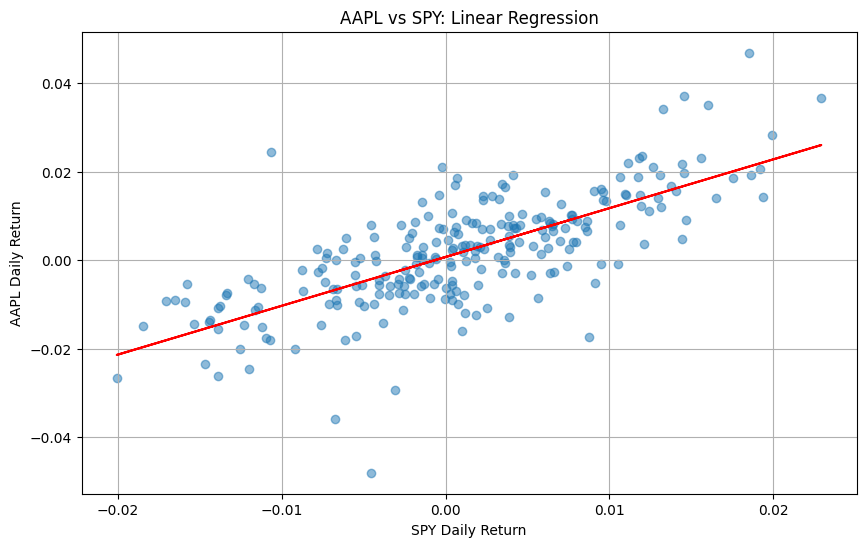

In [3]:
# Import necessary libraries
# To download historical stock data
import yfinance as yf
# For data manipulation
import pandas as pd
# For OLS regression modeling
import statsmodels.api as sm
# For data visualization
import matplotlib.pyplot as plt


# Download daily close prices for AAPL and SPY for the last 1 year
data = yf.download(['AAPL', 'SPY'], start='2023-01-01', end='2024-01-01')['Close']


# Drop rows with missing values (if any)
data = data.dropna()


# Calculate daily returns for AAPL and SPY
returns = data.pct_change().dropna()


# Define the dependent variable (Y) as AAPL returns
Y = returns['AAPL']


# Define the independent variable (X) as SPY returns
X = returns['SPY']


# Add a constant to X to include the intercept (β₀) in the regression
X = sm.add_constant(X)


# Fit the Ordinary Least Squares (OLS) regression model
model = sm.OLS(Y, X).fit()


# Print the regression results summary
print(model.summary())


# Plotting the regression line
plt.figure(figsize=(10, 6))  # Set the figure size
# Scatter plot of returns
plt.scatter(returns['SPY'], returns['AAPL'], alpha=0.5)
# Plot the fitted regression line
plt.plot(returns['SPY'], model.predict(X), color='red')

# Set plot title
plt.title("AAPL vs SPY: Linear Regression")
# X-axis label
plt.xlabel("SPY Daily Return")
# Y-axis label
plt.ylabel("AAPL Daily Return")

# Enable grid for readability
plt.grid(True)
# Display the plot
plt.show()